# Notebook Objective -  Retention within a nursery


In [45]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import geopandas as gpd

from shapely.geometry import LineString
from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import cmocean
import cmocean.cm as cmo

import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors


In [46]:
import utils

In [47]:
extents = utils.extents


In [29]:
# importlib.reload(utils)
# # Import necessary data and functions from utils
# hypotheses = utils.hypotheses
# stages = utils.stages
# locations = utils.locations
# start_years = utils.start_years
# months_data = utils.months_data
# extents = utils.extents

# #function
# plot_all_boxes = utils.plot_all_boxes
# plot_basemap = utils.plot_basemap

In [30]:
# # Load Utils
# locations = utils.locations
# boxes = {key: value['boxes'] for key, value in locations.items()}
# location_labels = {key: value['label'] for key, value in locations.items()}
# location_colors = {key: value['color'] for key, value in locations.items()}
# location_order = {key: value['order'] for key, value in locations.items()}

# months = months_data
# month_colors = {key: value['color'] for key, value in months_data.items()}
# month_labels = {key: value['label'] for key, value in months_data.items()}
# month_order = {key: value['order'] for key, value in months_data.items()}

# stages = utils.stages
# stage_colors = {key: value['color'] for key, value in stages.items()}
# stage_labels = {key: value['label'] for key, value in stages.items()}
# stage_markers = {key: value['marker'] for key, value in stages.items()}

# hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
# hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
# hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

# extent = extents['base']

In [48]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/hi-res-AP/'
data_path = repo_path + 'data/'
output_path = '/Users/zephyrsylvester/repos/hi-res-AP/processed_data/'
ibsco_path = data_path + 'IBSCO/'

fig_path = repo_path + 'figures/'
tab_path = fig_path + 'tables/'
map_path = fig_path + 'maps/'


In [49]:
# Plotting Data
# Path to the downloaded NetCDF file
# nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_APregion.nc'
nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_SWSect.nc'

# Open the NetCDF file using xarray
ds = xr.open_dataset(nc_path)


In [66]:
# Quick Check
# Extract the bathymetry data
bathymetry = ds['z']

# Tell it what to plot
to_plot = bathymetry

# # Define depth intervals (e.g., every 500 meters)
# depth_intervals = np.arange(-9000, 1000, 500)  # Adjust the range as needed

# # Plot the contours
# plt.figure(figsize=(15, 10))
# contour = plt.contourf(to_plot['lon'], to_plot['lat'], to_plot,
#                        levels=depth_intervals, cmap=cmo.ice)

# plt.colorbar(contour, label='Depth (m)')
# plt.title('Cropped IBCSO v2 Bed Bathymetry with 500m Contours')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.show()

In [51]:
# Read in your data!
summary_file = 'nursery_use_summary_inbound.csv'
traj_file = 'processed_trajectories_21dfilter_inbound.csv'
# output_nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84_500m_APregion.nc'
# ap_bathymetry.to_netcdf(output_nc_path)
summary=pd.read_csv(output_path + summary_file) 
df_traj=pd.read_csv(output_path + traj_file) 

In [52]:
# Names, Orders, Etc
locations = ['BS', 'GERL', 'GP', 'MB']
location_labels = {'BS': 'Bransf.', 'GERL': 'Gerl.', 'GP': 'Grand.', 'MB':'M. Bay'}
location_order = ['BS', 'GERL', 'GP', 'MB']

# Define location colors (replace with actual values)
location_colors = {
    'BS': '#d55e00',
    'GERL': '#029e73',
    'GP': '#cc78bc',
    'MB': '#0173b2',
    'outside': 'gray'
}

# Define region coordinates
boxes = {
    'BS': [
        {'lonpoly': [-62.0, -60.0, -60.0, -62.0], 'latpoly': [-63.7, -63.7, -62.6, -62.6]},
        {'lonpoly': [-60.0, -58.0, -58.0, -60.0], 'latpoly': [-63.5, -63.5, -62.5, -62.5]}
    ],
    'GERL': {'lonpoly': [-63.9, -61.5, -60.4, -62.4], 'latpoly': [-64.7, -63.6, -64.0, -65.3]},
    'GP': {'lonpoly': [-68.4, -64.5, -62.4, -66.0], 'latpoly': [-66.7, -64.5, -65.3, -67.4]},
    'MB': {'lonpoly': [-72.3, -69.5, -66.0, -68.0], 'latpoly': [-69.1, -67.5, -68.5, -69.7]}
}

# Names, Orders, Etc
hypotheses = {'hi_res'}
hypothesis_labels = {'hi_res': 'HR Ice'}
hypothesis_order = ['hi_res']

# Define the extent of the plot
extent = [275, 311, -72, -59]

# C3 Manuscript Standard Plot Window
extent_AP_base = [275, 311, -72, -59]

extent_AP_expand = [274, 316 -71, -60]

extent_AP_toSG = [281.6, 322, -65, -60]
extent_AP_toAM = [271, 308, -71, -62]

# Quick Plot

In [53]:
# Helper function to plot the base map and all boxes
def plot_all_boxes(ax, extent, boxes, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
    gl = ax.gridlines(linewidth=.5, color='black', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))

    # Plot all bounding boxes
    for region, coords in boxes.items():
        if isinstance(coords, list):
            # Multiple subregions
            for subregion in coords:
                lonpoly = subregion['lonpoly']
                latpoly = subregion['latpoly']
                poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='black', zorder=box_zorder, transform=ccrs.PlateCarree())
                ax.add_patch(poly)
        else:
            # Single region
            lonpoly = coords['lonpoly']
            latpoly = coords['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='black', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)


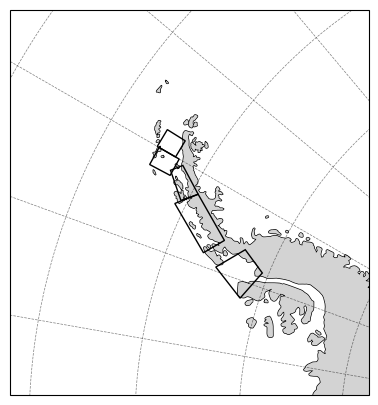

In [54]:
# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes


In [55]:
# Helper function to plot the base map and all boxes
def plot_all_boxes(ax, extent, boxes, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}

    # Plot all bounding boxes
    for region, coords in boxes.items():
        if isinstance(coords, list):
            # Multiple subregions
            for subregion in coords:
                lonpoly = subregion['lonpoly']
                latpoly = subregion['latpoly']
                poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor=location_colors[region], zorder=box_zorder, transform=ccrs.PlateCarree())
                ax.add_patch(poly)
        else:
            # Single region
            lonpoly = coords['lonpoly']
            latpoly = coords['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor=location_colors[region], zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)

    # Add legend
    legend_handles = [Line2D([0], [0], color=location_colors[loc], lw=2, label=location_labels[loc]) for loc in location_order]
    ax.legend(handles=legend_handles, loc='upper left', title='Nurseries')


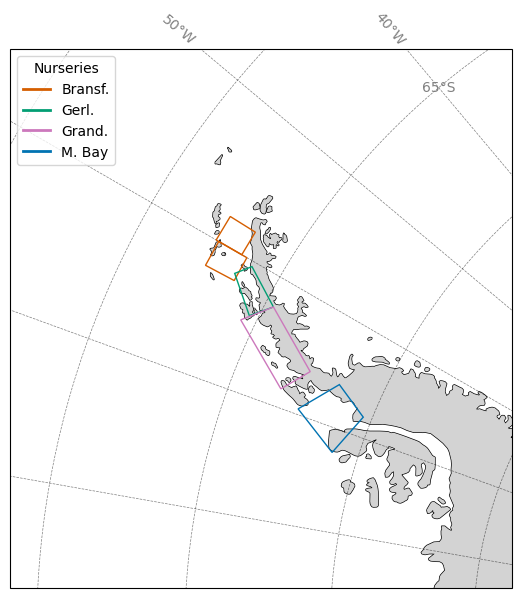

In [56]:

# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes

# Add title and labels
# plt.title('Regional Boundaries in the Antarctic', fontsize=15)
plt.show()


# Add IBSCO Bathy

In [57]:
# Tighten colormap
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

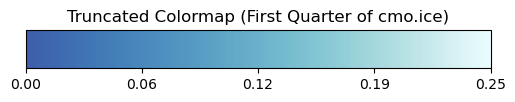

In [58]:
cmap=cmo.ice

# Create a truncated colormap
truncated_cmap = truncate_colormap(cmo.ice, 0.4, 1)

# Plot the truncated colormap
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create a color bar with the truncated colormap
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=truncated_cmap),
    cax=ax, orientation='horizontal', ticks=np.linspace(0, 1, 5)
)
cbar.ax.set_xticklabels([f'{x:.2f}' for x in np.linspace(0, 0.25, 5)])

# Add title and labels
cbar.ax.set_title('Truncated Colormap (First Quarter of cmo.ice)')

# Show the plot
plt.show()

In [59]:

# Helper function to plot the base map and all boxes
def plot_all_boxes(ax, extent, boxes, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)


    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
    gl.xlabel_style = {'size': 8, 'color': 'gray'}
    gl.ylabel_style = {'size': 8, 'color': 'gray'}
    
    # Plot all bounding boxes
    for region, coords in boxes.items():
        if isinstance(coords, list):
            # Multiple subregions
            for subregion in coords:
                lonpoly = subregion['lonpoly']
                latpoly = subregion['latpoly']
                poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor=location_colors[region], zorder=box_zorder, transform=ccrs.PlateCarree())
                ax.add_patch(poly)
        else:
            # Single region
            lonpoly = coords['lonpoly']
            latpoly = coords['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor=location_colors[region], zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)

    # Add legend
    legend_handles = [Line2D([0], [0], color=location_colors[loc], lw=2, label=location_labels[loc]) for loc in location_order]
    ax.legend(handles=legend_handles, loc='upper left', title='Nurseries')

In [67]:
# Define depth intervals (e.g., every 500 meters)
depth_int_500 = np.arange(-10000, 0, 500)  # Adjust the range as needed
depth_int_1000 = np.arange(-6000, 1000, 1000)  # Adjust the range as needed


In [68]:

# Helper function to plot the base map and all boxes
def plot_refmap(ax, extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
    gl.xlabel_style = {'size': 8, 'color': 'gray'}
    gl.ylabel_style = {'size': 8, 'color': 'gray'}
    

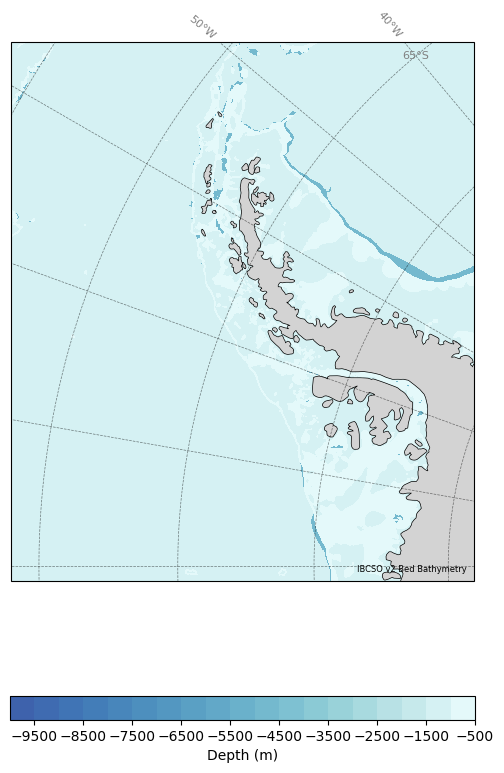

In [69]:
# Define depth intervals (e.g., every 500 meters)
depth_int = depth_int_500
cmap = truncated_cmap
extent=extents['hires']

# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_refmap(ax, extent)  # Plot all regions' bounding boxes

# Plot the bathymetry contours on the same axis
contour = ax.contourf(bathymetry['lon'], bathymetry['lat'], bathymetry, levels=depth_int, cmap=cmap, transform=ccrs.PlateCarree(), zorder=0)
plt.colorbar(contour, ax=ax, label='Depth (m)', orientation='horizontal', shrink = 0.6)

# Add small text in the bottom right corner
plt.annotate('IBCSO v2 Bed Bathymetry', 
             xy=(1, 0), xycoords='axes fraction', fontsize=6,
             xytext=(-5, 5), textcoords='offset points',
             ha='right', va='bottom')

# Add title and labels
# plt.title('500m Contours', fontsize=12)
plt.savefig(map_path+'500m-Reference-Map.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

## Nursery Plots

In [1]:
# Define depth intervals (e.g., every 500 meters)
depth_int = depth_int_500
cmap = truncated_cmap

# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes

# Plot the bathymetry contours on the same axis
contour = ax.contourf(bathymetry['lon'], bathymetry['lat'], bathymetry, levels=depth_int, cmap=cmap, transform=ccrs.PlateCarree(), zorder=0)
plt.colorbar(contour, ax=ax, label='Depth (m)', orientation='horizontal', shrink = 0.6)

# Add small text in the bottom right corner
plt.annotate('IBCSO v2 Bed Bathymetry', 
             xy=(1, 0), xycoords='axes fraction', fontsize=6,
             xytext=(-5, 5), textcoords='offset points',
             ha='right', va='bottom')

# Add title and labels
# plt.title('500m Contours', fontsize=12)
plt.savefig(map_path+'500m-Nursery-Map.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

NameError: name 'depth_int_500' is not defined

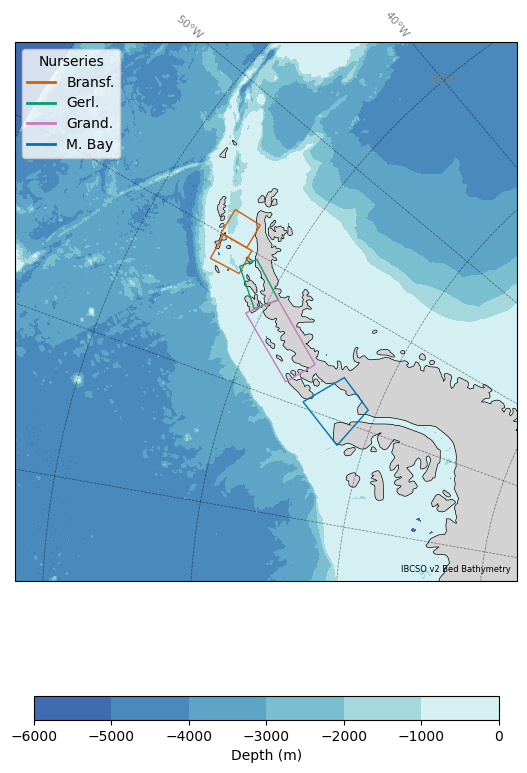

In [81]:
# Define depth intervals (e.g., every 500 meters)
depth_int = depth_int_1000

# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(), 'facecolor': '#4989bc'})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes

# Plot the bathymetry contours on the same axis
contour = ax.contourf(bathymetry['lon'], bathymetry['lat'], bathymetry, levels=depth_int, cmap=cmap, transform=ccrs.PlateCarree(), zorder=0)
plt.colorbar(contour, ax=ax, extend='both', label='Depth (m)', orientation='horizontal', shrink = 0.6)

# Add small text in the bottom right corner
plt.annotate('IBCSO v2 Bed Bathymetry', 
             xy=(1, 0), xycoords='axes fraction', fontsize=6,
             xytext=(-5, 5), textcoords='offset points',
             ha='right', va='bottom')

# Add title and labels
# plt.title('1000m Contours', fontsize=12)
plt.savefig(map_path+'Nursery-Map-1000m.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

array([-1000])

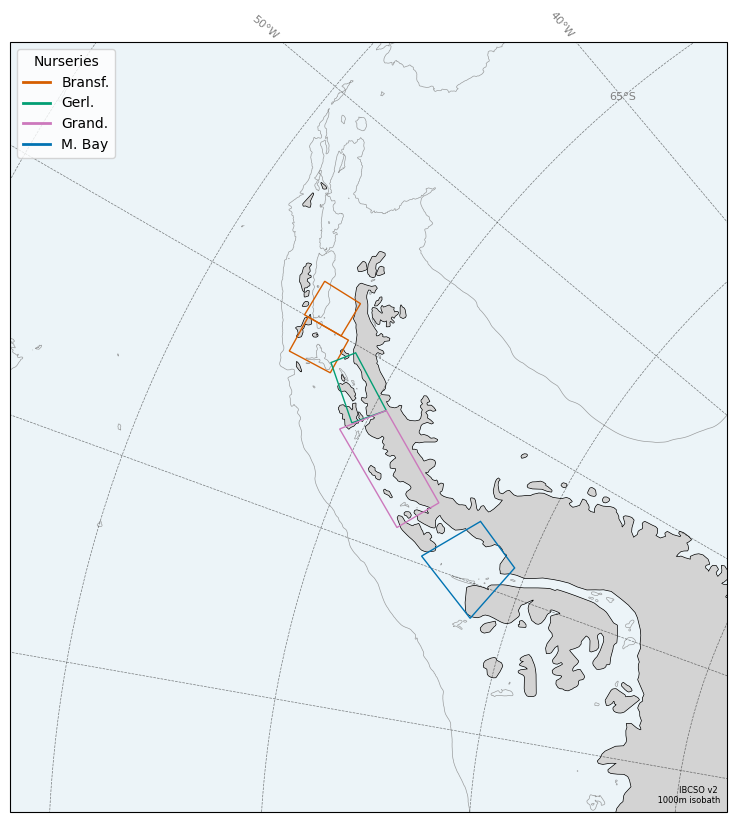

In [95]:
# Define depth intervals 
depth_int_1k_m = np.arange(-1000, 0, 1000)  # Adjust the range as needed
depth_int = depth_int_1k_m


# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo(), 'facecolor': '#ecf4f8'})
plot_all_boxes(ax, extent, boxes)  # Plot all regions' bounding boxes

# Plot the bathymetry contours on the same axis using contour for lines
contour = ax.contour(bathymetry['lon'], bathymetry['lat'], bathymetry,
                     levels=depth_int, linestyles = 'solid', linewidths=0.5, colors='grey', alpha=0.75,
                     transform=ccrs.PlateCarree(), zorder=0)

# Add small text in the bottom right corner
plt.annotate('IBCSO v2 \n 1000m isobath', 
             xy=(1, 0), xycoords='axes fraction', fontsize=6,
             xytext=(-5, 5), textcoords='offset points',
             ha='right', va='bottom')

# Add title and labels
# plt.title('1000m Contours', fontsize=12)
plt.savefig(map_path+'Nursery-Map-contours_1k_m.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()